In [1]:
import numpy as np
import matplotlib . pyplot as plt
import os

In [2]:
np. random . seed (2025)
n, p, k = 500 , 50, 8
sigma = 1.0

m = 10
Z = np. random . randn (n, m)
A = np. random . randn (m, p) * 0.8
X = Z.dot(A) + 0.1 * np. random . randn (n, p)

w_true = np. zeros (p)
w_true [:k] = np. linspace (5.0 , 1.0 , k) * np. random . choice ([1 , -1], k)
y = X.dot( w_true ) + sigma * np. random . randn (n)

idx = np. random . permutation (n)
train_idx , test_idx = idx [:350] , idx [350:]
X_train , y_train = X[ train_idx ], y[ train_idx ]
X_test , y_test = X[ test_idx ], y[ test_idx ]

def ridge_closed_form (X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective (X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)
    

def ridge_grad (X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent (X, y, lam , s, alpha , beta ):
    w = np.zeros(X.shape[1])
    obj_values = []

    for _ in range(1000):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w = w - t * grad
        obj_values.append(ridge_objective(X, y, w, lam))
    return w, obj_values

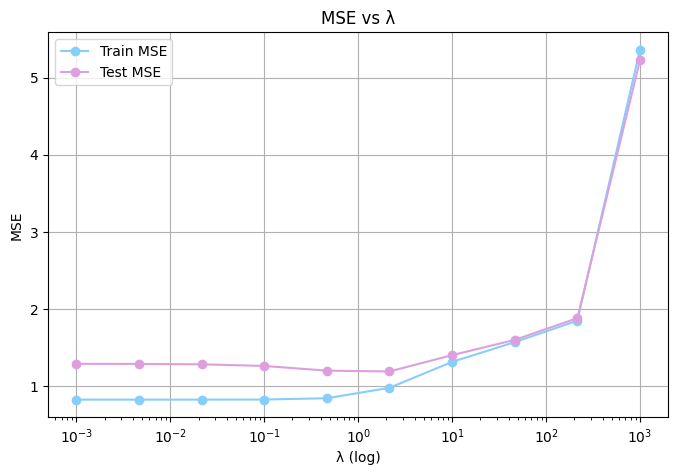

In [ ]:
lambdas = np.logspace(-3, 3, 10)  
train_errors = []
test_errors = []

for lam in lambdas:
    w_est = ridge_closed_form(X_train, y_train, lam)

    y_pred_train = X_train @ w_est
    y_pred_test  = X_test  @ w_est

    train_mse = np.mean((y_pred_train - y_train)**2)
    test_mse  = np.mean((y_pred_test - y_test)**2)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

plt.figure(figsize=(8,5))
plt.semilogx(lambdas, train_errors, '-o', label="Train MSE", color='lightskyblue')
plt.semilogx(lambdas, test_errors, '-o', label="Test MSE", color='plum')
plt.xlabel("λ (log)")
plt.ylabel("MSE")
plt.title("MSE vs λ")
plt.grid(True)
plt.legend()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "MSE10.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

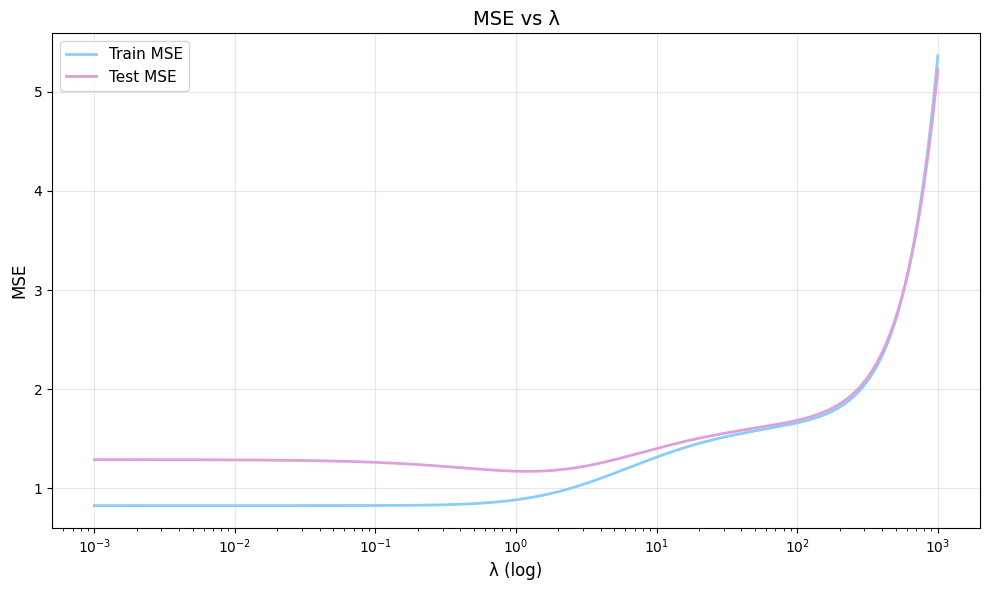

Optimal λ: 1.2053
Minimum Test MSE: 1.1716
Train MSE at optimal λ: 0.9016


In [ ]:
lambdas = np.logspace(-3, 3, 1000)  


train_mses = []
test_mses = []

for lam in lambdas:
    w_lambda = ridge_closed_form(X_train, y_train, lam)
    
    y_train_pred = X_train @ w_lambda
    y_test_pred = X_test @ w_lambda
    
    train_mse = np.mean((y_train - y_train_pred)**2)
    test_mse = np.mean((y_test - y_test_pred)**2)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, train_mses,  label='Train MSE', linewidth=2, color='lightskyblue')

plt.plot(lambdas, test_mses,  label='Test MSE', linewidth=2, color='plum')
plt.xscale('log')
plt.xlabel('λ (log)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('MSE vs λ', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "MSE1000.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

optimal_idx = np.argmin(test_mses)
optimal_lambda = lambdas[optimal_idx]
optimal_test_mse = test_mses[optimal_idx]

print(f"Optimal λ: {optimal_lambda:.4f}")
print(f"Minimum Test MSE: {optimal_test_mse:.4f}")
print(f"Train MSE at optimal λ: {train_mses[optimal_idx]:.4f}")

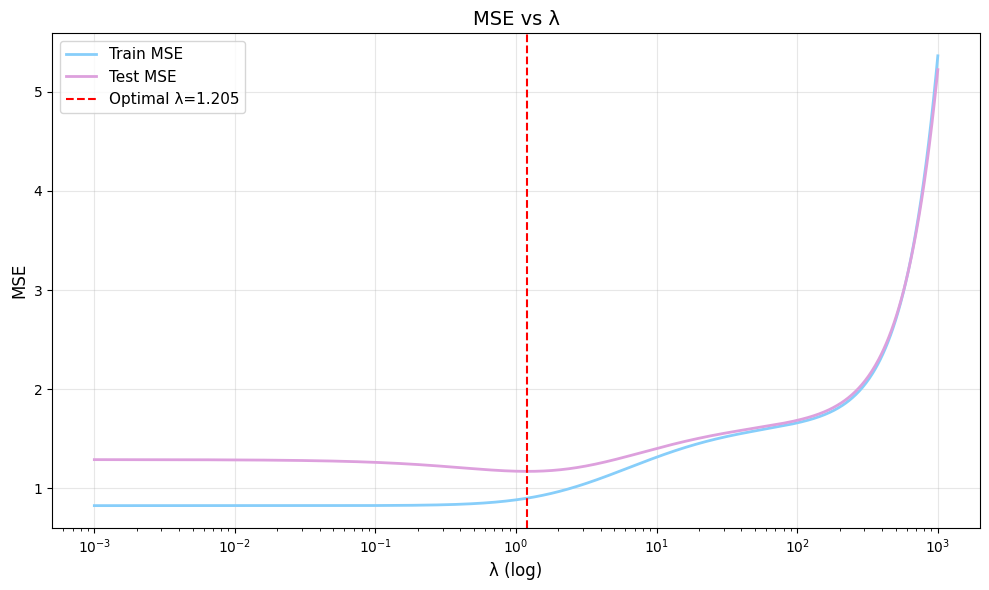

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(lambdas, train_mses,  label='Train MSE', linewidth=2, color='lightskyblue')
plt.plot(lambdas, test_mses, label='Test MSE', linewidth=2, color='plum')
plt.axvline(optimal_lambda, color='red', linestyle='--', linewidth=1.5, label=f'Optimal λ={optimal_lambda:.3f}')
plt.xscale('log')
plt.xlabel('λ (log)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('MSE vs λ', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "MSE_opt_lambda.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()